## *Alaa Asfour, Jason Quantrill, Million Solomon, Murrium Zaheer, Xiaodan Bi*
 500854838, 501036139, 501280237, 500269037, 501049279  
{alaa.asfour, jason.quantrill, million.solomon, mzaheer, xiaodan.bi}@torontomu.ca  
Computer Science Department, Toronto Metropolitan University, Toronto, Canada

# Emotion-Powered Spotify Music Player
###Classification of OAHEGA with ResNet50

# Preprocessing

In [ ]:
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.17.1
Keras version: 3.5.0


In [ ]:
import sys

print(sys.version)


3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]


# Loading and Unzipping the Dataset

In [ ]:
from google.colab import drive
import zipfile
import os
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_file_path = '/content/drive/MyDrive/CV_Project/OAHEGA/AffectNet.zip'

# Unzipping the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/AffectNet')

# Checking the structure of the unzipped folder
os.listdir('/content/AffectNet')

['dataset', 'data.csv']

# Loading the CSV File and Preparing Image Paths and Labels

In [ ]:
import pandas as pd
import os

# Read the CSV file using pandas
csv_file_path = '/content/AffectNet/data.csv'  #the path to our .csv file
df = pd.read_csv(csv_file_path)

# Filter out rows where the label is "Ahegao"
filtered_df = df[df['label'] != 'Ahegao']

# Extracting file paths and labels from the filtered DataFrame
image_paths = filtered_df['path'].values
labels = filtered_df['label'].values

# Defining the base directory where the images are located
base_dir = '/content/AffectNet/dataset'  # the base directory of the images

# Combine the base directory with the paths from the CSV
image_paths = [os.path.join(base_dir, path) for path in image_paths]

# Print the first few file paths and labels to check
print("Sample image paths (excluding 'Ahegao'):", image_paths[:5])
print("Sample labels (excluding 'Ahegao'):", labels[:5])



Sample image paths (excluding 'Ahegao'): ['/content/AffectNet/dataset/Surprise/1bd930d6a1c717c11be33db74823f661cb53f86cbba1d3d1f336cdf9~12fffff.jpg', '/content/AffectNet/dataset/Surprise/cropped_emotions.100096~12fffff.png', '/content/AffectNet/dataset/Surprise/0df0e470e33093f5b72a8197fa209d684032cc17f68194e605a26897~12fffff.jpg', '/content/AffectNet/dataset/Surprise/cropped_emotions.260779~12fffff.png', '/content/AffectNet/dataset/Surprise/cropped_emotions.263616~12fffff.png']
Sample labels (excluding 'Ahegao'): ['Surprise' 'Surprise' 'Surprise' 'Surprise' 'Surprise']


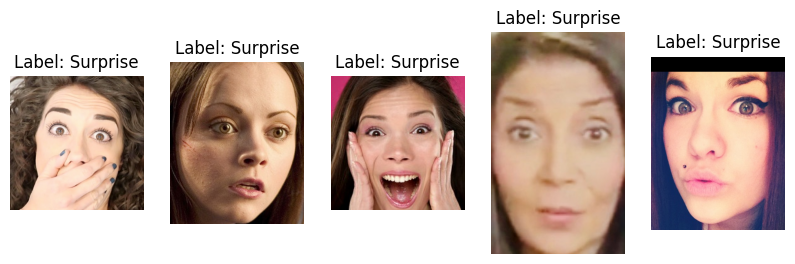

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Function to load and display images
def display_sample_images(image_paths, labels, num_images=5):
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        # Load the image from the file
        image = tf.io.read_file(image_paths[i])
        image = tf.image.decode_image(image, channels=3)

        # Display the image
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(image.numpy().astype("uint8"))  # Convert to uint8 for display
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.show()

# Display sample images
display_sample_images(image_paths, labels)


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import KFold

# Function to preprocess images (resize and normalize)
def preprocess_image(img_path, label):
    # Load the image from the file
    image = tf.io.read_file(img_path)
    image = tf.image.decode_image(image, channels=3)  # Use decode_image for multiple formats

    # Ensure the image tensor has a known shape
    image.set_shape([None, None, 3])

    # Resize the image to 224x224 (required input size for ResNet50)
    image = tf.image.resize(image, (224, 224))

    # Normalize the image to the [0, 1] range
    image = image / 255.0
    return image, label

# Convert labels to integer indices (if needed)
label_to_index = {label: index for index, label in enumerate(np.unique(labels))}
labels = np.array([label_to_index[label] for label in labels])

# One-hot encode the labels
labels = tf.keras.utils.to_categorical(labels)


# Splitting the Data into Training, Validation, and Test Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into 90% for training/validation and 10% for the test set
train_val_image_paths, test_image_paths, train_val_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.1, random_state=42
)

# Print the number of samples in each set
print(f"Training/Validation set size: {len(train_val_image_paths)}")
print(f"Test set size: {len(test_image_paths)}")


Training/Validation set size: 12823
Test set size: 1425


# Creating a Model Initialization Function, ResNet50

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Function to create and compile the ResNet50 model
def create_model():
    # Load the pre-trained ResNet50 model
    base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

    # Fine-tune the last layer
    for layer in base_model.layers[-1:]:
        layer.trainable = True

    # Build the model
    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)  # Use the base model in inference mode
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)  # Add a dropout layer to prevent overfitting
    outputs = Dense(len(label_to_index), activation='softmax')(x)  # Adjusting the output layer for the emotion classes

    model = Model(inputs, outputs)

    # Compile the model with categorical_crossentropy
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


# 5-Fold Cross-Validation

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# Initialize KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Variables to store performance across folds
fold_accuracies = []
fold_losses = []

# 5-fold cross-validation on the training/validation set
for fold, (train_index, val_index) in enumerate(kf.split(train_val_image_paths)):
    print(f"Starting fold {fold + 1}...")

    train_image_paths = np.array(train_val_image_paths)[train_index]
    val_image_paths = np.array(train_val_image_paths)[val_index]
    train_labels = train_val_labels[train_index]
    val_labels = train_val_labels[val_index]

    train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))
    val_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_labels))

    train_dataset = train_dataset.map(preprocess_image).batch(32).shuffle(1000)
    val_dataset = val_dataset.map(preprocess_image).batch(32)

    model = create_model()

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history = model.fit(train_dataset, validation_data=val_dataset, epochs=20, callbacks=[early_stopping, reduce_lr])

    val_loss, val_accuracy = model.evaluate(val_dataset)
    fold_losses.append(val_loss)
    fold_accuracies.append(val_accuracy)

    print(f"Fold {fold + 1} - Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")

average_loss = np.mean(fold_losses)
average_accuracy = np.mean(fold_accuracies)

print(f"Average Loss: {average_loss:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")


Starting fold 1...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 152s 257ms/step - accuracy: 0.5960 - loss: 1.0119 - val_accuracy: 0.2624 - val_loss: 1.9234 - learning_rate: 1.0000e-04
Epoch 2/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 53s 149ms/step - accuracy: 0.8888 - loss: 0.3023 - val_accuracy: 0.4511 - val_loss: 1.4375 - learning_rate: 1.0000e-04
Epoch 3/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 53s 147ms/step - accuracy: 0.9568 - loss: 0.1265 - val_accuracy: 0.7762 - val_loss: 0.7742 - learning_rate: 1.0000e-04
Epoch 4/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 53s 148ms/step - accuracy: 0.9754 - loss: 0.0699 - val_accuracy: 0.7766 - val_loss: 0.8158 - learning_rate: 1.0000e-04
Epoch 5/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 53s 148ms/step - accuracy: 0.9797 - loss: 0.0652 - val_accuracy: 0.7661 - val_loss: 1.1178 - learning_rate: 1.0000e-04
Epoch 6/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 53s 148ms/step - accuracy: 0.9817 - loss: 0.0548 - val_accuracy: 0.7661 - val_loss: 1.1427 - l

# Evaluating

In [ ]:
# Create TensorFlow dataset for the test set
test_dataset = tf.data.Dataset.from_tensor_slices((test_image_paths, test_labels))
test_dataset = test_dataset.map(preprocess_image).batch(32)

# Evaluate the model on the unseen test dataset (using the last trained model)
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.8386 - loss: 0.7100
Test Loss: 0.7096
Test Accuracy: 0.8428


# Saving the Model

In [ ]:
# Save the model
model.save('MobileNet_OAHEGA_1.keras')
print("Model saved successfully as 'MobileNet_OAHEGA.keras'")

Model saved successfully as 'MobileNet_OAHEGA.keras'


# Metrics

# Accuracy and Loss vs Epoch

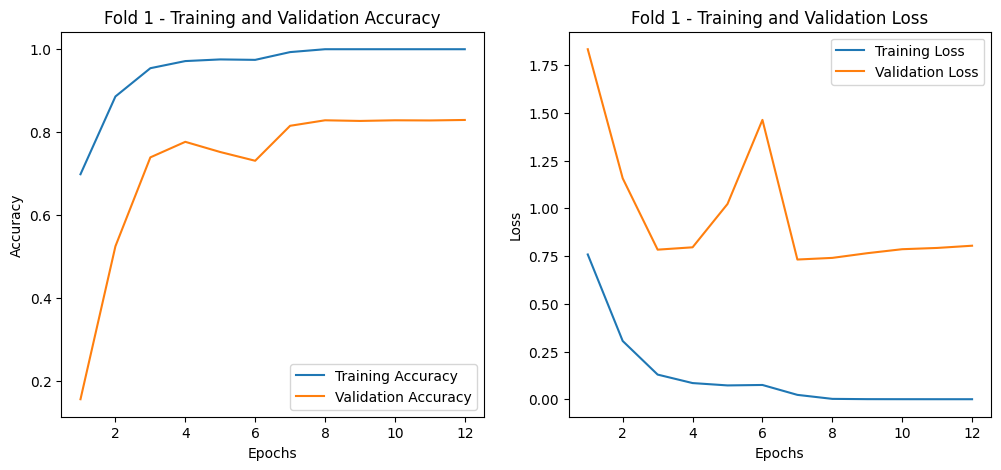

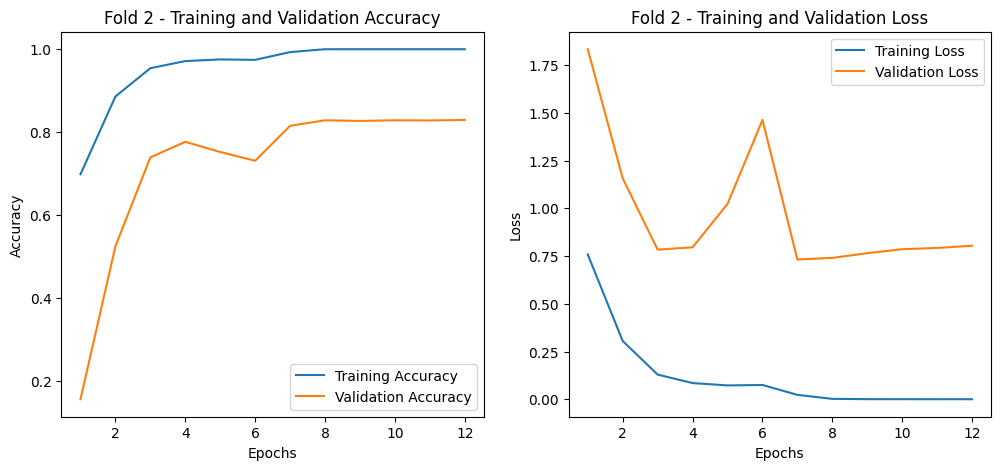

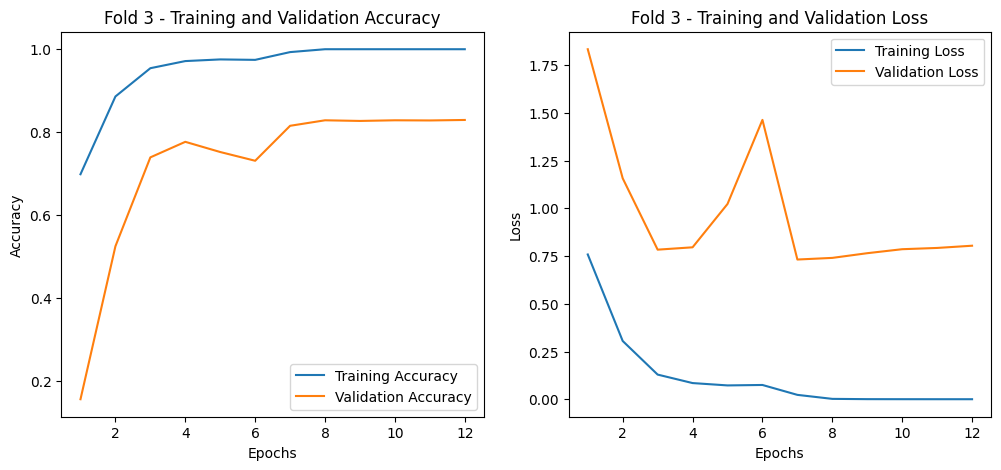

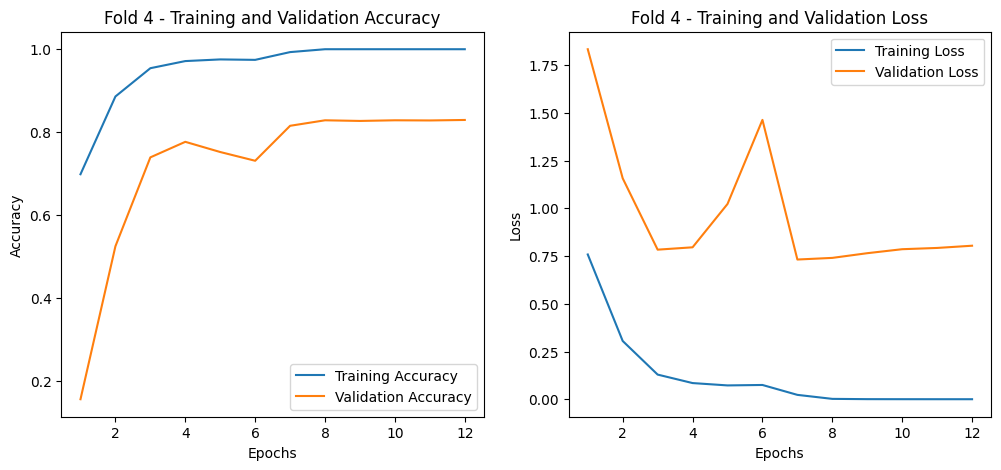

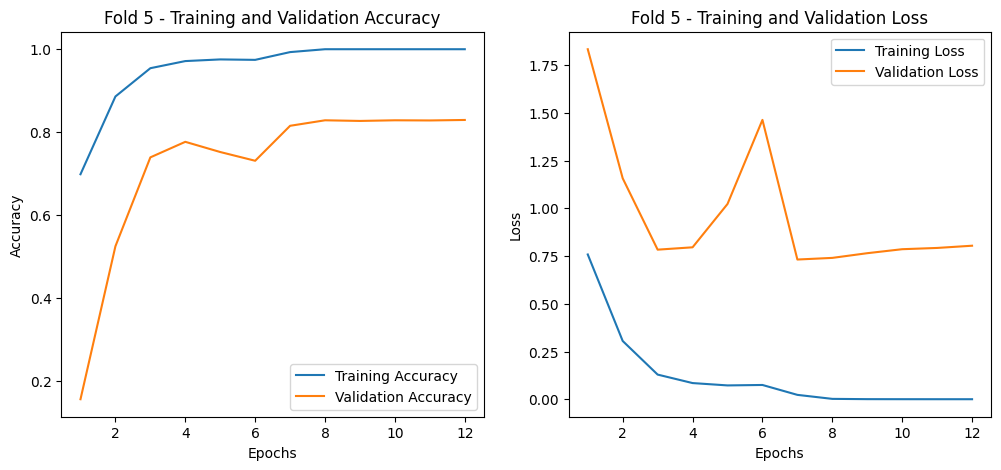

In [ ]:
import matplotlib.pyplot as plt

# Function to plot training and validation accuracy and loss
def plot_training_history(history, fold):
    # Extract accuracy and loss from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Plot accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'Fold {fold} - Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'Fold {fold} - Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Example usage for each fold
for fold in range(1, 6):
    plot_training_history(history, fold)


# Classification Metrics for Each Fold

81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step
Fold 1 - Classification Report:
               precision    recall  f1-score      support
0              0.773869  0.743961  0.758621   207.000000
1              0.947289  0.905036  0.925681   695.000000
2              0.735589  0.784759  0.759379   748.000000
3              0.768176  0.793201  0.780488   706.000000
4              0.925287  0.774038  0.842932   208.000000
accuracy       0.815523  0.815523  0.815523     0.815523
macro avg      0.830042  0.800199  0.813420  2564.000000
weighted avg   0.820425  0.815523  0.816986  2564.000000
Fold 1 - AUC Score: 0.9636


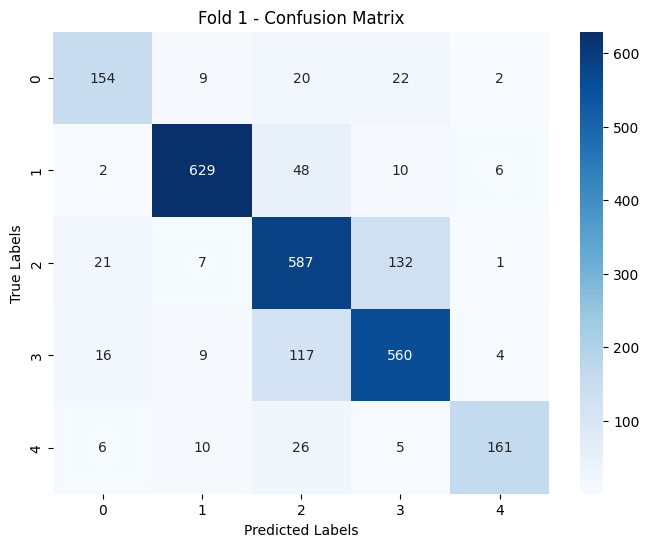

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
Fold 2 - Classification Report:
               precision    recall  f1-score      support
0              0.773869  0.743961  0.758621   207.000000
1              0.947289  0.905036  0.925681   695.000000
2              0.735589  0.784759  0.759379   748.000000
3              0.768176  0.793201  0.780488   706.000000
4              0.925287  0.774038  0.842932   208.000000
accuracy       0.815523  0.815523  0.815523     0.815523
macro avg      0.830042  0.800199  0.813420  2564.000000
weighted avg   0.820425  0.815523  0.816986  2564.000000
Fold 2 - AUC Score: 0.9636


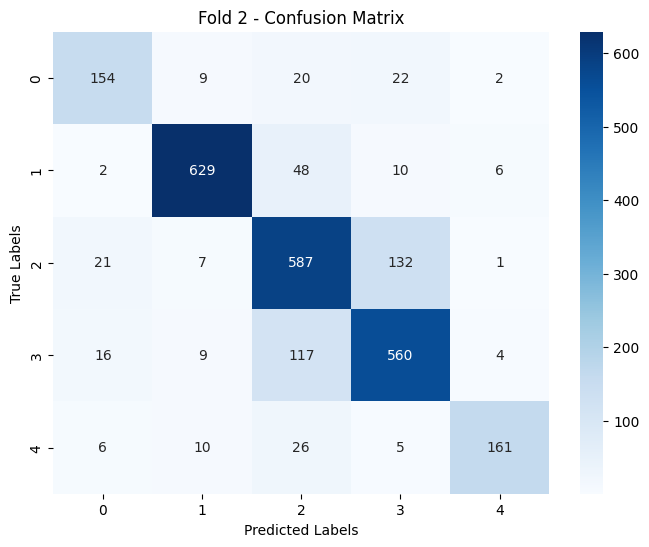

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
Fold 3 - Classification Report:
               precision    recall  f1-score      support
0              0.773869  0.743961  0.758621   207.000000
1              0.947289  0.905036  0.925681   695.000000
2              0.735589  0.784759  0.759379   748.000000
3              0.768176  0.793201  0.780488   706.000000
4              0.925287  0.774038  0.842932   208.000000
accuracy       0.815523  0.815523  0.815523     0.815523
macro avg      0.830042  0.800199  0.813420  2564.000000
weighted avg   0.820425  0.815523  0.816986  2564.000000
Fold 3 - AUC Score: 0.9636


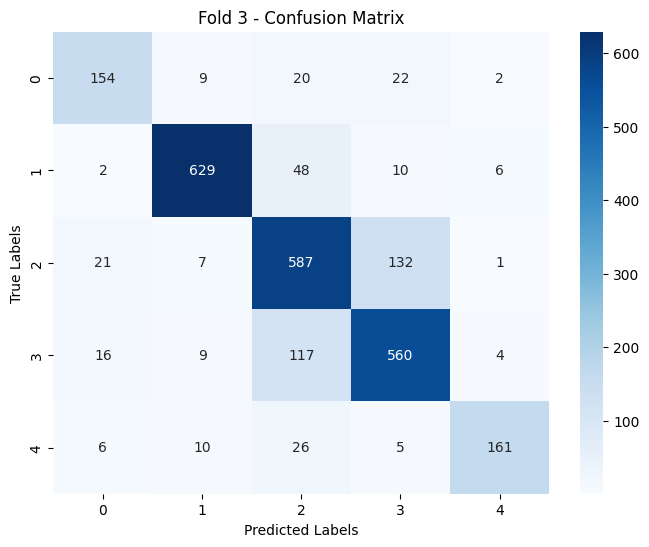

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
Fold 4 - Classification Report:
               precision    recall  f1-score      support
0              0.773869  0.743961  0.758621   207.000000
1              0.947289  0.905036  0.925681   695.000000
2              0.735589  0.784759  0.759379   748.000000
3              0.768176  0.793201  0.780488   706.000000
4              0.925287  0.774038  0.842932   208.000000
accuracy       0.815523  0.815523  0.815523     0.815523
macro avg      0.830042  0.800199  0.813420  2564.000000
weighted avg   0.820425  0.815523  0.816986  2564.000000
Fold 4 - AUC Score: 0.9636


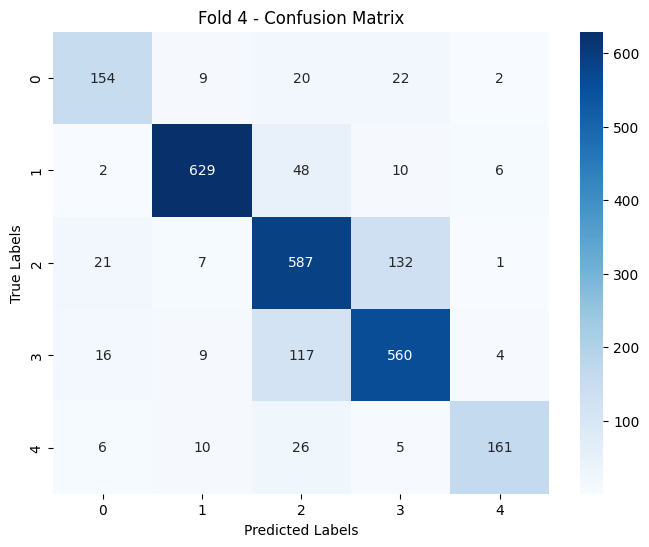

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
Fold 5 - Classification Report:
               precision    recall  f1-score      support
0              0.773869  0.743961  0.758621   207.000000
1              0.947289  0.905036  0.925681   695.000000
2              0.735589  0.784759  0.759379   748.000000
3              0.768176  0.793201  0.780488   706.000000
4              0.925287  0.774038  0.842932   208.000000
accuracy       0.815523  0.815523  0.815523     0.815523
macro avg      0.830042  0.800199  0.813420  2564.000000
weighted avg   0.820425  0.815523  0.816986  2564.000000
Fold 5 - AUC Score: 0.9636


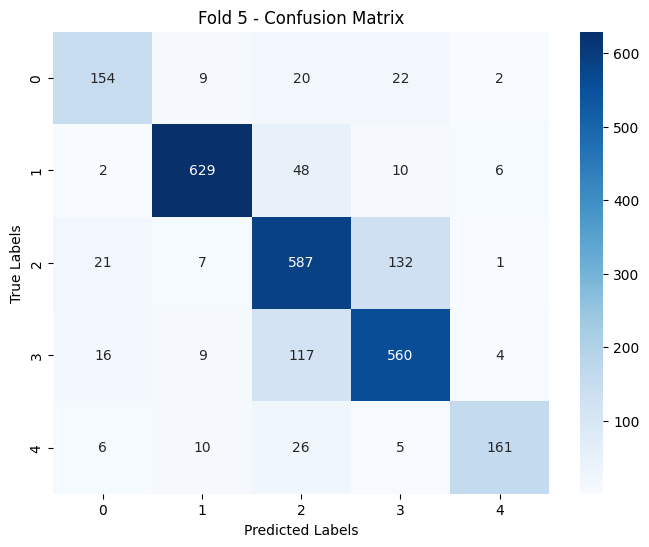

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd
import seaborn as sns

# Function to evaluate and display classification metrics
def evaluate_metrics(model, val_dataset, val_labels, fold):
    # Predict the labels
    predictions = model.predict(val_dataset)
    y_pred = predictions.argmax(axis=1)
    y_true = val_labels.argmax(axis=1)

    # Classification report
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    print(f"Fold {fold} - Classification Report:\n", df_report)

    # AUC for each class
    auc_score = roc_auc_score(y_true, predictions, multi_class='ovr')
    print(f"Fold {fold} - AUC Score: {auc_score:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Fold {fold} - Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

# Example usage for each fold
for fold in range(1, 6):
    evaluate_metrics(model, val_dataset, val_labels, fold)


# ROC Curves for Each Fold

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


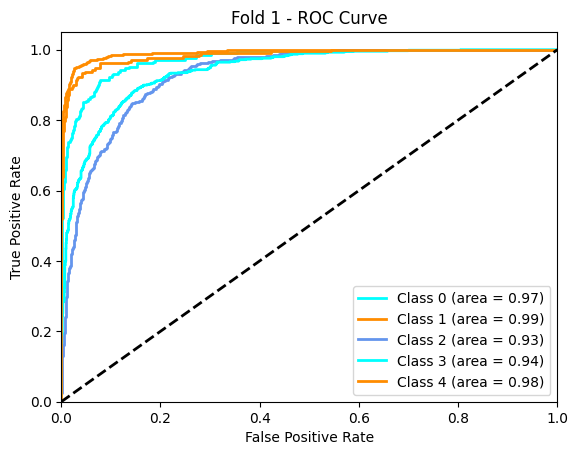

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


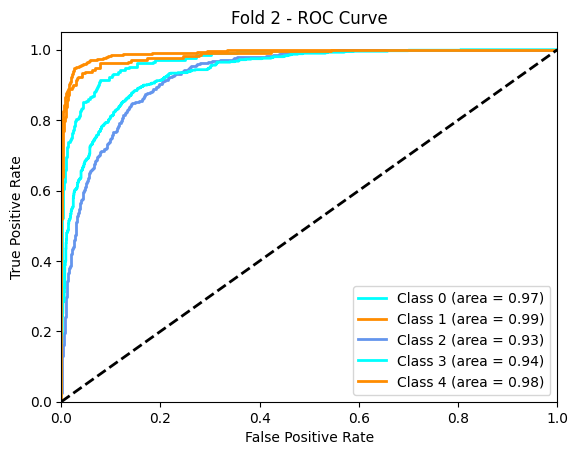

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step


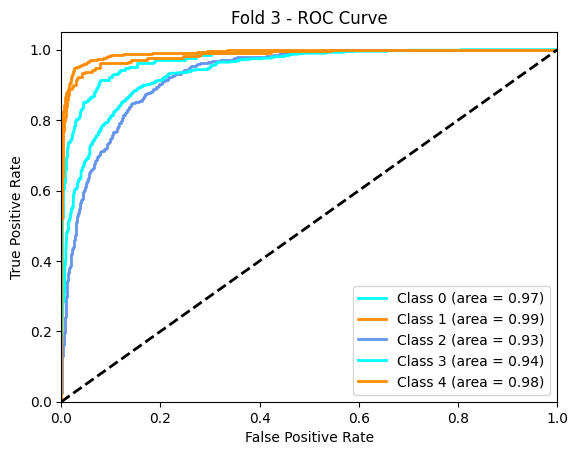

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


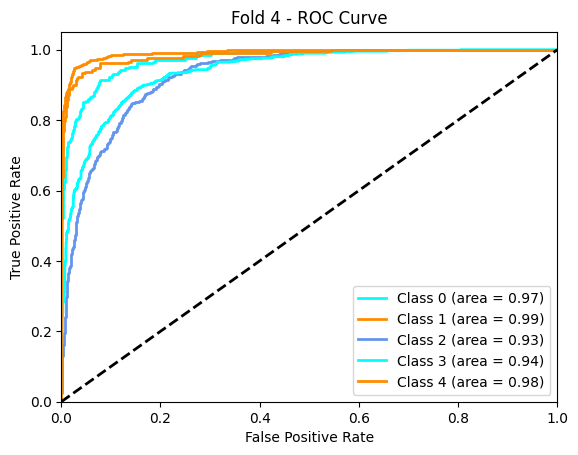

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


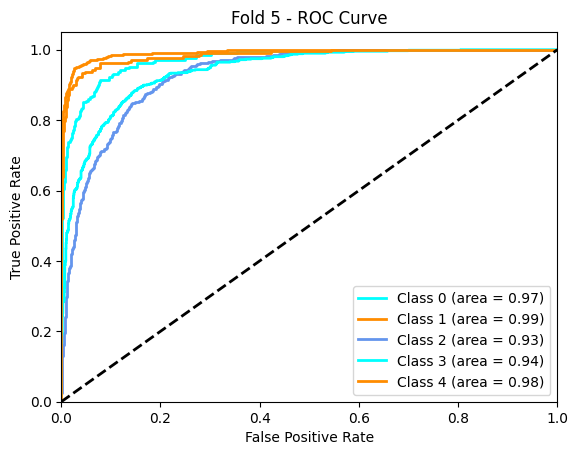

In [ ]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

def plot_roc_curve(y_true, y_pred, fold):
    n_classes = y_true.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute ROC curve and ROC area for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure()
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Fold {fold} - ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

# Example usage for each fold
for fold in range(1, 6):
    y_true = val_labels  # True one-hot encoded labels
    y_pred = model.predict(val_dataset)  # Predicted probabilities
    plot_roc_curve(y_true, y_pred, fold)


# Aggregate Metrics for All Folds

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# Create a DataFrame to store metrics for all folds
metrics_summary = pd.DataFrame(columns=['Fold', 'Precision', 'Recall', 'F1-Score', 'AUC'])

for fold in range(1, 6):
    # Predict the labels for the validation set
    predictions = model.predict(val_dataset)
    y_pred = predictions.argmax(axis=1)
    y_true = val_labels.argmax(axis=1)

    # Calculate the classification report and extract metrics
    report = classification_report(y_true, y_pred, output_dict=True)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']

    # Calculate the AUC score
    auc_score = roc_auc_score(y_true, predictions, multi_class='ovr')

    # Create a DataFrame for the current fold metrics
    fold_metrics = pd.DataFrame({
        'Fold': [fold],
        'Precision': [precision],
        'Recall': [recall],
        'F1-Score': [f1_score],
        'AUC': [auc_score]
    })

    # Concatenate the current fold metrics with the overall metrics_summary DataFrame
    metrics_summary = pd.concat([metrics_summary, fold_metrics], ignore_index=True)

# Display the summary
print(metrics_summary)




81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
 5/81 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

<ipython-input-14-d7e683fa8b77>:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_summary = pd.concat([metrics_summary, fold_metrics], ignore_index=True)


81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
  Fold  Precision    Recall  F1-Score       AUC
0    1   0.820425  0.815523  0.816986  0.963558
1    2   0.820425  0.815523  0.816986  0.963558
2    3   0.820425  0.815523  0.816986  0.963558
3    4   0.820425  0.815523  0.816986  0.963558
4    5   0.820425  0.815523  0.816986  0.963558


# Visualize Aggregate Metrics Across Folds

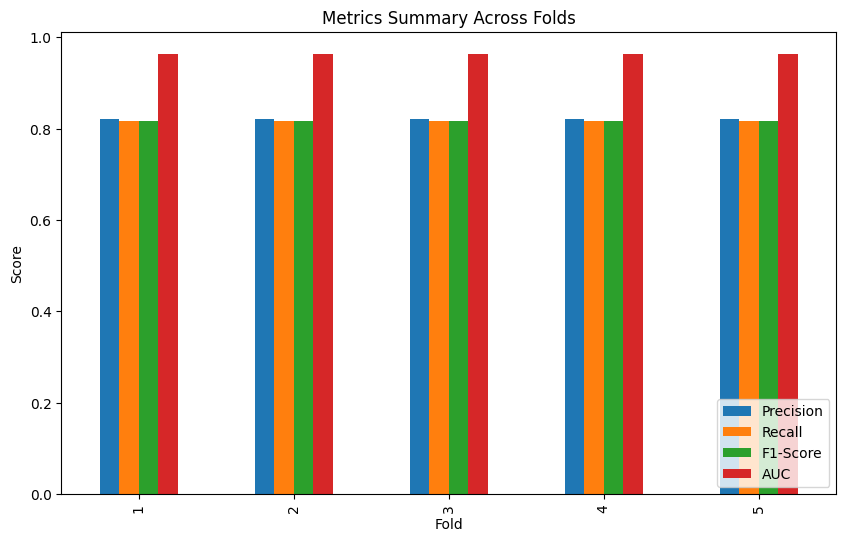

In [ ]:
# Plot aggregate metrics
metrics_summary.plot(x='Fold', y=['Precision', 'Recall', 'F1-Score', 'AUC'], kind='bar', figsize=(10, 6))
plt.title("Metrics Summary Across Folds")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.show()


# Saving System Information and Performance Metrics

In [ ]:
import json
import psutil
import time
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
import numpy as np

# Collect system info
system_info = {
    "cpu_count": psutil.cpu_count(),
    "memory_total": psutil.virtual_memory().total,
    "memory_available": psutil.virtual_memory().available,
    "gpus": [
        {
            "id": i,
            "name": gpu.name,
            "memory_total": tf.config.experimental.get_virtual_device_configuration(gpu)[0].memory_limit / (1024**2) if tf.config.experimental.get_virtual_device_configuration(gpu) else 'Not Available',
            "memory_free": 'Not Available',
            "temperature": "Not Available"
        }
        for i, gpu in enumerate(tf.config.experimental.list_physical_devices('GPU'))
    ] if tf.config.experimental.list_physical_devices('GPU') else "No GPU available"
}

# Collect metrics and details for each fold
fold_results = []

for fold in range(1, 6):
    start_time = time.time()

    # Evaluate the model on the validation set for this fold
    val_loss, val_accuracy = model.evaluate(val_dataset)
    inference_time = time.time() - start_time

    # Predictions and performance metrics
    y_true = []
    for images, labels in val_dataset:
        y_true.extend(labels.numpy())
    y_true = np.array(y_true)
    y_true = np.argmax(y_true, axis=-1)

    # Get predictions from the model
    y_pred_probs = model.predict(val_dataset)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Compute classification metrics
    classification_metrics = classification_report(y_true, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_pred_probs, multi_class="ovr")

    # Store results for this fold
    fold_results.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "classification_metrics": classification_metrics,
        "confusion_matrix": conf_matrix.tolist(),
        "auc_roc": auc_roc,
        "inference_time": inference_time
    })

# Aggregate and save the experiment details
experiment_details = {
    "model": "ResNet50",
    "pretrain_dataset": "ImageNet",
    "training_dataset": "OAHEGA",
    "system_info": system_info,
    "model_architecture": "ResNet50 with custom dense layers",
    "training_config": {
        "batch_size": 32,
        "epochs": len(history.history['accuracy']),
        "optimizer": {
            "name": "adam",
            "learning_rate": 1e-4
        },
        "loss_function": "categorical_crossentropy"
    },
    "fold_results": fold_results,
    "average_metrics": {
        "average_accuracy": np.mean([result["val_accuracy"] for result in fold_results]),
        "average_loss": np.mean([result["val_loss"] for result in fold_results]),
        "average_auc_roc": np.mean([result["auc_roc"] for result in fold_results])
    }
}

# Save to JSON file
with open('experiment_metrics.json', 'w') as f:
    json.dump(experiment_details, f, indent=4)

print("Metrics and system information saved to 'experiment_metrics.json'")


81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8269 - loss: 0.6483
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8269 - loss: 0.6483
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8269 - loss: 0.6483
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8269 - loss: 0.6483
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8269 - loss: 0.6483
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
Metrics and system information saved to 'experiment_metrics.json'
